<a href="https://colab.research.google.com/github/AnjanaGunarathna/DL_News_Detection/blob/Samudra(CNN)/DLAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Required Libraries:

In [2]:
!pip install kaggle tensorflow scikit-learn

Mount Drive & Load Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

fake_df = pd.read_csv('/content/drive/MyDrive/Fake.csv')
true_df = pd.read_csv('/content/drive/MyDrive/True.csv')

fake_df['label'] = 0
true_df['label'] = 1

df = pd.concat([fake_df[['title','text','label']], true_df[['title','text','label']]], ignore_index=True)

df['text'] = df['title'] + ' ' + df['text']
df = df[['text','label']]

Mounted at /content/drive


Text Preprocessing

In [4]:
import re
def preprocess_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower().strip()
    return text

df['text'] = df['text'].apply(preprocess_text)


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)


Tokenization & Padding

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 150
max_len = 150

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, padding='post', maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, padding='post', maxlen=max_len)

Build Text CNN Model

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),
    Conv1D(128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.build(input_shape=(None, max_len))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 128)       │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 146, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,889 (460.50 KB)

 Trainable params: 117,889 (460.50 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [7]:
history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8801 - loss: 0.2752 - val_accuracy: 0.9729 - val_loss: 0.0728
Epoch 2/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9768 - loss: 0.0671 - val_accuracy: 0.9782 - val_loss: 0.0599
Epoch 3/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9858 - loss: 0.0433 - val_accuracy: 0.9735 - val_loss: 0.0723
Epoch 4/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9920 - loss: 0.0241 - val_accuracy: 0.9814 - val_loss: 0.0579
Epoch 5/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9958 - loss: 0.0142 - val_accuracy: 0.9786 - val_loss: 0.0742
Epoch 6/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9964 - loss: 0.0105 - val_accuracy: 0.9784 - val_loss: 0.0675
Epoch 7/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9980 - loss: 0.0070 - val_accuracy: 0.9818 - val_loss: 0.0644
Epoch 8/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9977 - loss: 0.0069 - val_accuracy: 

Evaluate Model

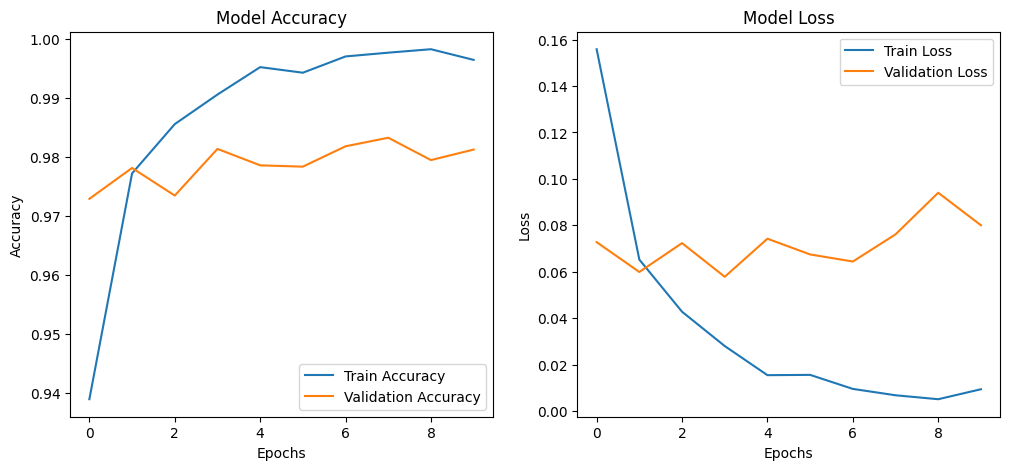


Test Accuracy: 98.13%
Test Loss: 0.0800
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Confusion Matrix:
 [[4672   61]
 [ 107 4140]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      4733
           1       0.99      0.97      0.98      4247

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980


Performance – Text CNN Model

Metric     Training Set    Test Set       
----------------------------------------
Accuracy   0.9965          0.9813         
Loss       0.0094          0.0800         


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=0)


train_accuracy = history.history['accuracy'][-1]
train_loss = history.history['loss'][-1]


print("\nPerformance – Text CNN Model\n")
print(f"{'Metric':<10} {'Training Set':<15} {'Test Set':<15}")
print(f"{'-'*40}")
print(f"{'Accuracy':<10} {train_accuracy:<15.4f} {test_accuracy:<15.4f}")
print(f"{'Loss':<10} {train_loss:<15.4f} {test_loss:<15.4f}")



Confusion Matrix

281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


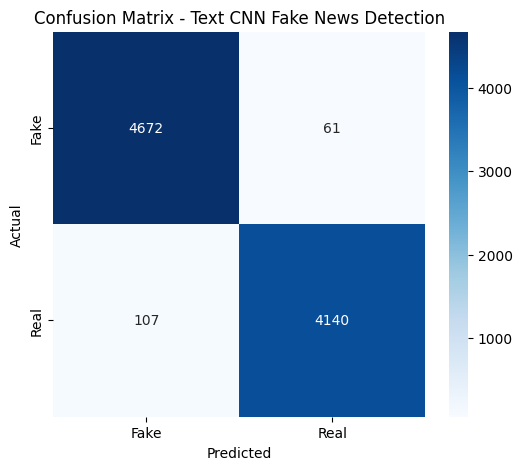

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Text CNN Fake News Detection')
plt.show()

Full Detection

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Fake News Detector")
print("Type 'exit' to quit.\n")

while True:
    news_text = input("Enter news article: ")

    if news_text.lower() == "exit":
        print("Exiting the detector. Goodbye! 👋")
        break

    new_text = [news_text]

    new_seq = tokenizer.texts_to_sequences(new_text)
    new_padded = pad_sequences(new_seq, maxlen=150)


    prediction = model.predict(new_padded)


    if prediction[0][0] > 0.5:
        print("This news is classified as REAL")
    else:
        print("This news is classified as FAKE")

    print("Confidence score:", float(prediction[0][0]))
    print("\n----------------------------\n")



Fake News Detector
Type 'exit' to quit.

Enter news article: Israeli opposition politicians back Trump's peace plan published at 12:52 12:52 Leader of the Opposition in Israel Yair Lapid and leader of Israel's Democrats party Yair Golan have called on Netanyahu to move forward with President Trump's peace plan. "At this moment, our collective mission is not to allow any — neither Hamas nor Netanyahu and his government any opportunity to sabotage Trump's agreement," Golan posts on X. The leader of the Democrats party says Israel should "move forward and fight with all means" to ensure an agreement is implemented, hostages are released, Hamas' rule ends and the Gaza Strip is reconstructed. Lapid says he has told the US administration that Israel's Prime Minister Netanyahu has the political backing to continue the process to end the war. "Israel should announce it is joining the discussions led by the president to finalize the details of the deal" Lapid writes on X.
1/1 ━━━━━━━━━━━━━━━━━━